# Round Numbers — a quantitative teardown 🔬
### Real tape · chi-square clustering · HAC fade · random-level control · cost sweep

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a random level?: Not supported](https://img.shields.io/badge/Beats_a_random_level%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the two things the lore conflates — price-level **clustering** (real, and old news) and **forecastability** of a fade (absent) — and show the fade can't even beat a random-level placebo.

> ⚠️ **Not investment advice.** Basket ^GSPC/SPY/AAPL/MSFT, daily (`quantlab.data`, Yahoo); single names in `raw` (as-traded nominal), index/ETF in `split_only`; fade returns demeaned by each tape's drift; one-day execution lag. Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (round_numbers/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
from round_numbers import data, strategy

AS_OF = "2026-06-12"
BAND, HORIZON = 0.004, 1
names = data.load_basket(as_of=AS_OF)
fp = data.fingerprint([c.to_numpy() for _, _, c in names])
for t, g, c in names:
    print(f"{t:6} grid={g:6.0f}  {len(c):,} rows  {c.index[0].date()} -> {c.index[-1].date()}")
print("basket fingerprint =", fp)


^GSPC  grid=   100  9,179 rows  1990-01-02 -> 2026-06-12
SPY    grid=    10  8,400 rows  1993-01-29 -> 2026-06-12
AAPL   grid=    10  9,179 rows  1990-01-02 -> 2026-06-12
MSFT   grid=    10  9,179 rows  1990-01-02 -> 2026-06-12
basket fingerprint = 13ddddeac40e


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\93-round-numbers\round_numbers\data.py:132: UserWarning: AAPL: 5 daily move(s) beyond ±40% [2014-06-09, 2020-08-31, 2000-06-21, 2005-02-28, 2000-09-29] — almost certainly a data/adjustment artefact, not a market move. Inspect before publishing anything built on this series.
  raw = qdata.fetch(ticker, start=start, end=end, mode=mode, use_cache=use_cache)
C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\93-round-numbers\round_numbers\data.py:132: UserWarning: MSFT: 6 daily move(s) beyond ±40% [1994-05-23, 1990-04-16, 1999-03-29, 2003-02-18, 1996-12-09 (+1 more)] — almost certainly a data/adjustment artefact, not a market move. Inspect before publishing anything built on this series.
  raw = qdata.fetch(ticker, start=start, end=end, mode=mode, use_cache=use_cache)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `MIXED` | Real on the level — pooled chi² **380** (p ≈ 2.0e-76), 11.2% within 5% of a round number. None on the forecast — fade **-0.53 bps**/trade, HAC *t* **-0.18**. |
| **Tradability** | `MIRAGE` | Negative gross; net of 5 bps/leg **-10.53 bps**/trade. No edge to scale. |
| **Beats a random level?** | `NOT SUPPORTED` | Real fade beats random-level fade 43% of 200 seeds — a coin-flip. |

> 💡 **In plain words:** the magnetism is a property of the *ruler* (where prices like to sit), not of the *future* (where they go next).

## 1 · The claim, steelmanned

- **H₁ (clustering):** closes are non-uniformly distributed in their distance to the nearest round level — they pile up near it.
- **H₂ (forecast):** that proximity predicts a reversal away from the level — a fade earns a positive, autocorrelation-robust return.
- **H₃ (information):** the *round* levels do this better than *arbitrary* levels at the same frequency.

H₁ can be true while H₂ and H₃ are false — and that is exactly the split we find.

## 2 · So what? — what rides on each answer

If H₂/H₃ held, every liquid asset would carry a permanent, free mean-reversion signal. The clustering literature (Osborne 1962, Harris 1991) all but guarantees H₁; the open question — and the one the lore cashes in — is H₂.

## 3 · How we'd know — the protocol

Chi-square on the folded distance-to-round (per name + pooled) · fade as a drift-demeaned fixed-horizon event study with one-day lag · HAC *t* on the pooled trade returns · random-level control (phase-shifted grid, 200 seeds) · cost sweep. **Mirage trigger, declared up front:** a fade *t* below 2, or a real fade that fails to beat the random-level placebo.

## 4 · The teardown

**(a) Clustering** — per name and pooled chi-square:

In [2]:
rows = []
for t, g, c in names:
    r = strategy.clustering_test(c.to_numpy(), g)
    rows.append([t, r['n'], r['chi2'], r['p'], r['frac_near']*100])
allc = np.concatenate([c.to_numpy() for _, _, c in names])
rp = strategy.clustering_test(allc, 1.0)
rows.append(['POOLED($)', rp['n'], rp['chi2'], rp['p'], rp['frac_near']*100])
tbl = pd.DataFrame(rows, columns=['name', 'n', 'chi2', 'p', 'within 5% (%)']).set_index('name')
tbl

,n,chi2,p,within 5% (%)
name,,,,
^GSPC,9179,16.933108,4.977386e-02,9.717834
SPY,8400,34.171429,8.334814e-05,9.642857
AAPL,9179,50.296220,9.475222e-08,10.284345
MSFT,9179,67.698987,4.295387e-11,9.761412
POOLED($),35937,380.785291,1.716607e-76,11.152851


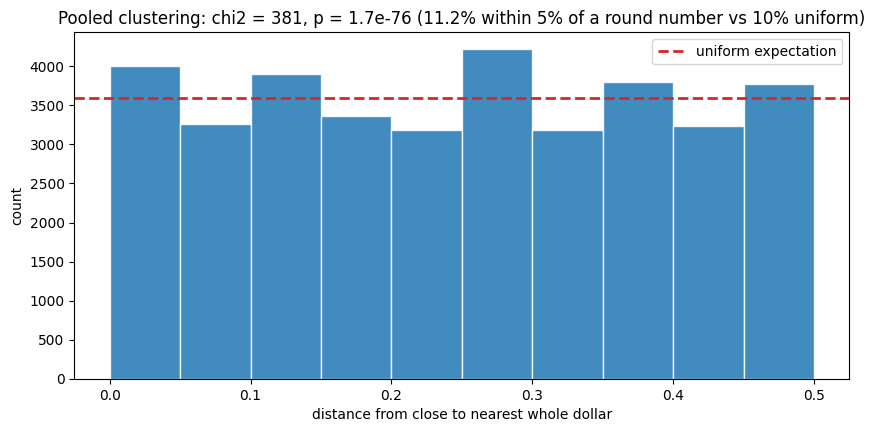

pooled n=35,937  chi2=380.8  p=1.7e-76  frac_near=11.2%


In [3]:
allc = np.concatenate([c.to_numpy() for _, _, c in names])
r = strategy.clustering_test(allc, 1.0)
dist = strategy.distance_to_round(allc, 1.0)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(dist, bins=10, range=(0, 0.5), alpha=.85, edgecolor='white')
ax.axhline(len(dist)/10, color='C3', ls='--', lw=2, label='uniform expectation')
ax.set_xlabel('distance from close to nearest whole dollar'); ax.set_ylabel('count')
ax.set_title(f"Pooled clustering: chi2 = {r['chi2']:.0f}, p = {r['p']:.1e} "
             f"({r['frac_near']*100:.1f}% within 5% of a round number vs 10% uniform)")
ax.legend(); plt.show()
print(f"pooled n={r['n']:,}  chi2={r['chi2']:.1f}  p={r['p']:.1e}  frac_near={r['frac_near']*100:.1f}%")

> 💡 **In plain words:** the single names (AAPL, MSFT) cluster hard; the index barely. That's the Harris (1991) shape — clustering is strongest in higher-priced, more-volatile single stocks. The *existence* of clustering is not in doubt.

**(b) Forecast** — the fade, with HAC inference, vs the random-level placebo (200 seeds):

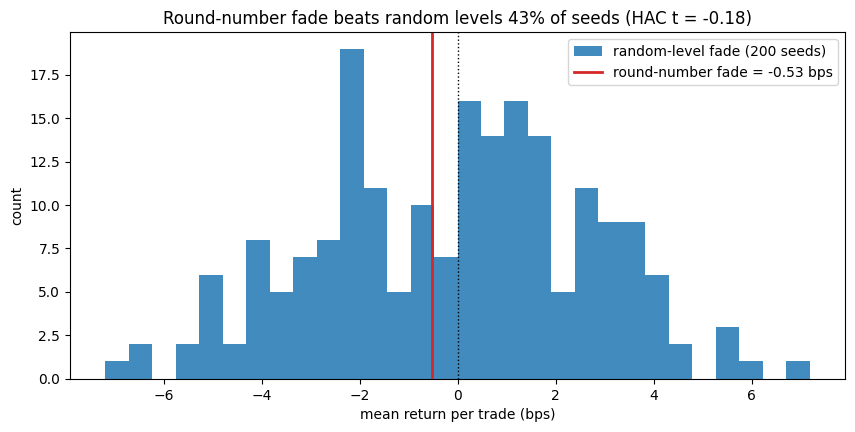

real fade: trades 4,642  mean -0.53 bps  HAC t -0.18
net of 5 bps/leg: -10.53 bps/trade
random-level: -0.10 bps (sd 2.77)  -> real beats 43% of seeds


In [4]:
real = strategy.pooled_fade(names, band=BAND, horizon=HORIZON)
t_real = strategy.hac_tstat(real)
net = strategy.net_of_costs(real, cost_bps=5.0)
rand = strategy.random_level_pool_means(names, n_seeds=200, band=BAND, horizon=HORIZON)
beats = (real.mean() > rand).mean()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(rand*1e4, bins=30, alpha=.85, label='random-level fade (200 seeds)')
ax.axvline(real.mean()*1e4, color='C3', lw=2, label=f'round-number fade = {real.mean()*1e4:+.2f} bps')
ax.axvline(0, color='k', lw=1, ls=':')
ax.set_xlabel('mean return per trade (bps)'); ax.set_ylabel('count'); ax.legend()
ax.set_title(f'Round-number fade beats random levels {beats*100:.0f}% of seeds (HAC t = {t_real:+.2f})')
plt.show()
print(f'real fade: trades {len(real):,}  mean {real.mean()*1e4:+.2f} bps  HAC t {t_real:+.2f}')
print(f'net of 5 bps/leg: {net.mean()*1e4:+.2f} bps/trade')
print(f'random-level: {rand.mean()*1e4:+.2f} bps (sd {rand.std()*1e4:.2f})  -> real beats {beats*100:.0f}% of seeds')

> 💡 **In plain words:** the real fade lands in the middle of the random-level cloud and leans negative. Round-ness adds no information a trader can bank; you'd do no better — slightly worse — fading arbitrary price levels.

**Cost sweep** — there is no break-even, because the gross edge is already below zero:

In [5]:
real = strategy.pooled_fade(names, band=BAND, horizon=HORIZON)
for cb in [0, 1, 2, 5, 10]:
    m = strategy.net_of_costs(real, cost_bps=cb).mean()*1e4
    print(f'cost {cb:2d} bps/leg -> {m:+7.2f} bps/trade')

cost  0 bps/leg ->   -0.53 bps/trade
cost  1 bps/leg ->   -2.53 bps/trade
cost  2 bps/leg ->   -4.53 bps/trade
cost  5 bps/leg ->  -10.53 bps/trade
cost 10 bps/leg ->  -20.53 bps/trade


## 5 · The verdict

Signal `MIXED` (clustering real: chi² 380, p ≈ 2.0e-76; forecast none: fade -0.53 bps, HAC *t* -0.18). Tradability `MIRAGE` (-10.53 bps/trade net). Beats a random level? `NOT SUPPORTED` (43% of 200 seeds). The harness *can* detect a planted bounce (the synthetic positive control banks it at HAC *t* ≈ +5.7) — there simply isn't one in the real tape.

## 6 · Could you trade it?

Capacity is irrelevant when the gross edge is negative. The binding fact is economic: a lumpy price *distribution* implies nothing about the *conditional mean of the next return*. The round numbers mark where price rests, not where it travels — and a spread-paying fade of them is a slow bleed.

## 7 · Going further

- Re-run on **intraday** bars (Harris's home turf) — does a higher-frequency fade survive?
- Decompose clustering by **price decade** and **volatility** to reproduce the Harris cross-section explicitly.
- Recast the round level as a **liquidity** marker (resting limit orders) rather than a directional one and test whether it predicts *spread*, not *return*.